#**Deep Learning for Image Classification**  
**Comparative Analysis of CNN and LSTM Models on the CIFAR-10 Dataset**


**Import Libraries**

In [26]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

**Load CIFAR-10 Dataset**

In [27]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

**Dataset Description**

In [28]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


**CIFAR-10 Class Names**

In [29]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

**Visualize Sample Images**

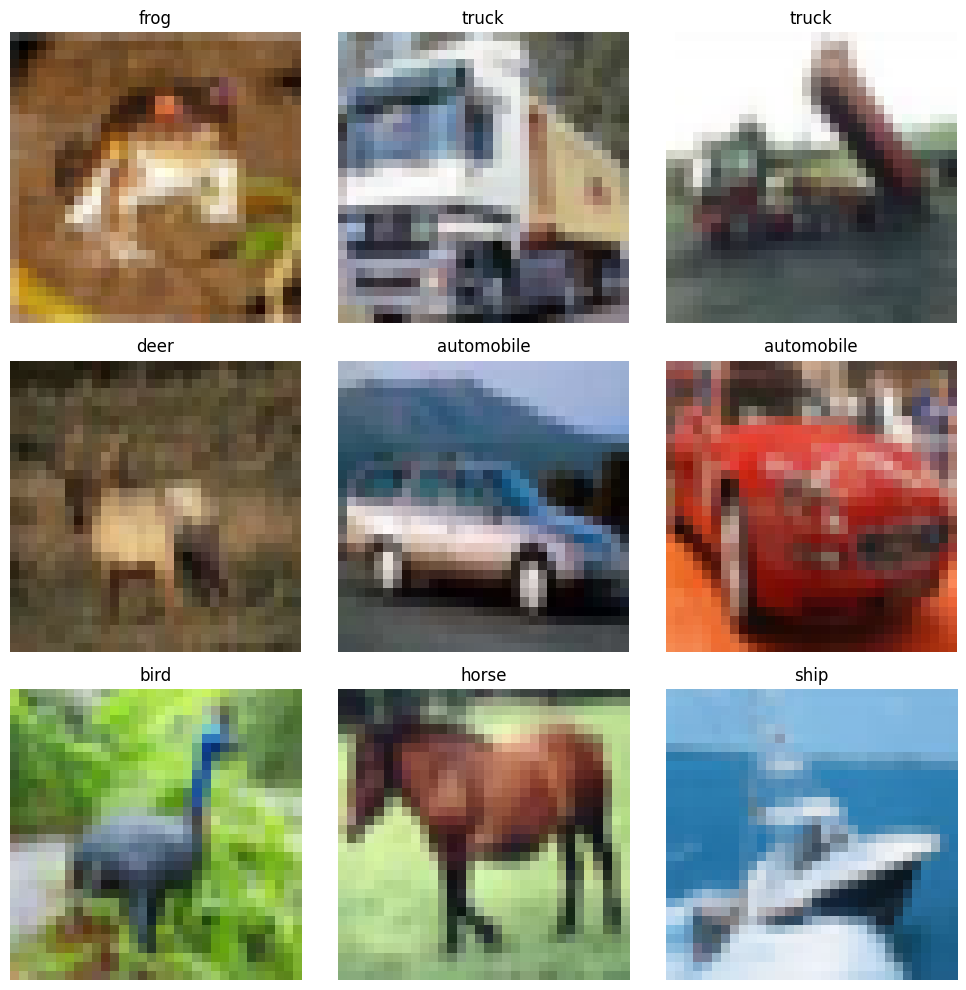

In [30]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Class Distribution (Bar Chart)**

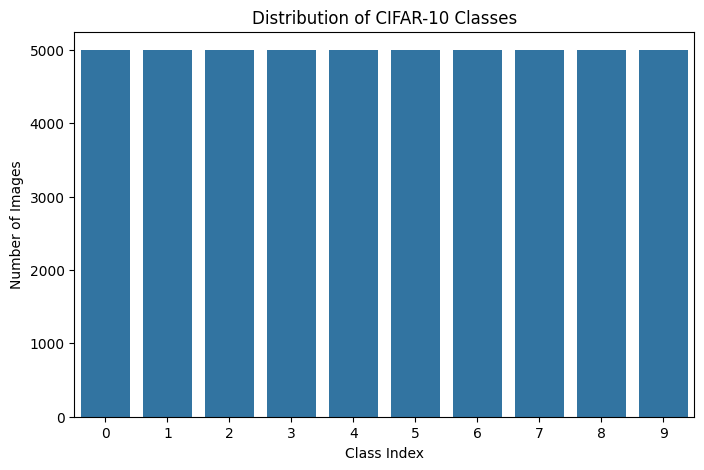

In [31]:
labels = y_train.flatten()

plt.figure(figsize=(8,5))
sns.countplot(x=labels)

plt.title("Distribution of CIFAR-10 Classes")
plt.xlabel("Class Index")
plt.ylabel("Number of Images")

plt.show()

**Data Preprocessing**

In [32]:
x_train = x_train / 255.0
x_test = x_test / 255.0

**Build CNN Model**

In [33]:
cnn_model = models.Sequential()

cnn_model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
cnn_model.add(layers.MaxPooling2D((2,2)))

cnn_model.add(layers.Conv2D(64,(3,3),activation='relu'))
cnn_model.add(layers.MaxPooling2D((2,2)))

cnn_model.add(layers.Conv2D(64,(3,3),activation='relu'))

cnn_model.add(layers.Flatten())
cnn_model.add(layers.Dense(64,activation='relu'))
cnn_model.add(layers.Dense(10,activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Compile CNN Model**

In [34]:
cnn_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

**Train CNN Model**

In [35]:
history_cnn = cnn_model.fit(
x_train,
y_train,
epochs=10,
validation_data=(x_test,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 49ms/step - accuracy: 0.3303 - loss: 1.7995 - val_accuracy: 0.5418 - val_loss: 1.3056
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.5623 - loss: 1.2208 - val_accuracy: 0.6006 - val_loss: 1.1298
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step - accuracy: 0.6268 - loss: 1.0620 - val_accuracy: 0.5977 - val_loss: 1.1430
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.6673 - loss: 0.9472 - val_accuracy: 0.6675 - val_loss: 0.9538
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6997 - loss: 0.8554 - val_accuracy: 0.6838 - val_loss: 0.9057
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.7166 - loss: 0.8004 - val_accuracy: 0.6910 - val_loss: 0.8947
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7395 - loss: 0.7479 - val_accuracy: 0.6960 - val_loss: 0.9075
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.7540 -

**CNN Accuracy Line Chart**

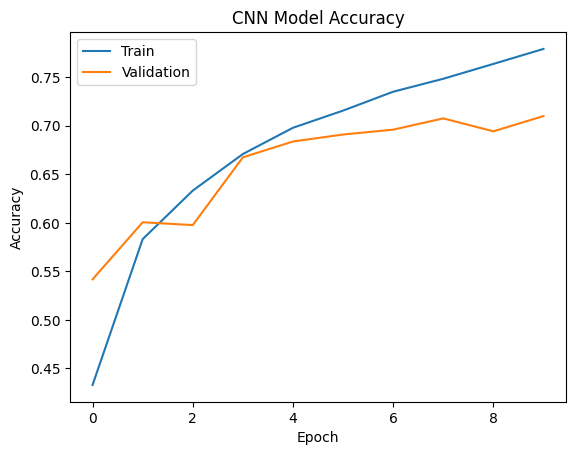

In [36]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

**CNN Loss Line Chart**

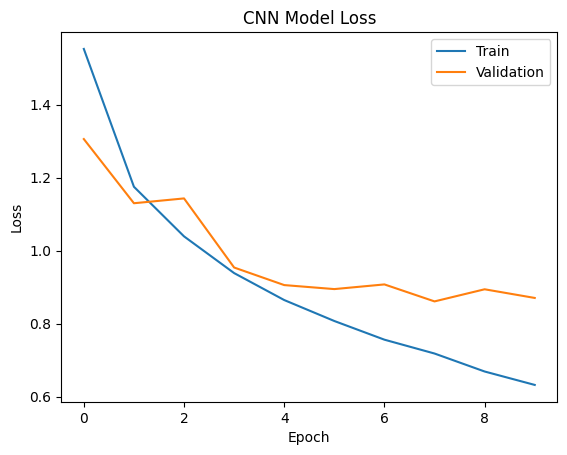

In [37]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

**Evaluate CNN Model**

In [38]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test,y_test)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7151 - loss: 0.8638
CNN Test Accuracy: 0.7099999785423279


**Prepare Data for LSTM**

In [39]:
x_train_lstm = x_train.reshape(50000,32,96)
x_test_lstm = x_test.reshape(10000,32,96)

**Build LSTM Model**

In [40]:
lstm_model = models.Sequential()

lstm_model.add(layers.LSTM(128,input_shape=(32,96)))
lstm_model.add(layers.Dense(64,activation='relu'))
lstm_model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compile LSTM Model**

In [41]:
lstm_model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

**Train LSTM Model**

In [42]:
history_lstm = lstm_model.fit(
x_train_lstm,
y_train,
epochs=10,
validation_data=(x_test_lstm,y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.2779 - loss: 1.9464 - val_accuracy: 0.3977 - val_loss: 1.6371
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.4224 - loss: 1.5798 - val_accuracy: 0.4660 - val_loss: 1.4767
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.4789 - loss: 1.4365 - val_accuracy: 0.5077 - val_loss: 1.3656
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.5105 - loss: 1.3465 - val_accuracy: 0.5140 - val_loss: 1.3364
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.5413 - loss: 1.2703 - val_accuracy: 0.5411 - val_loss: 1.2710
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 50ms/step - accuracy: 0.5645 - loss: 1.2079 - val_accuracy: 0.5448 - val_loss: 1.2647
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.5823 - loss: 1.1672 - val_accuracy: 0.5478 - val_loss: 1.2552
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.5986 -

**LSTM Accuracy Line Chart**

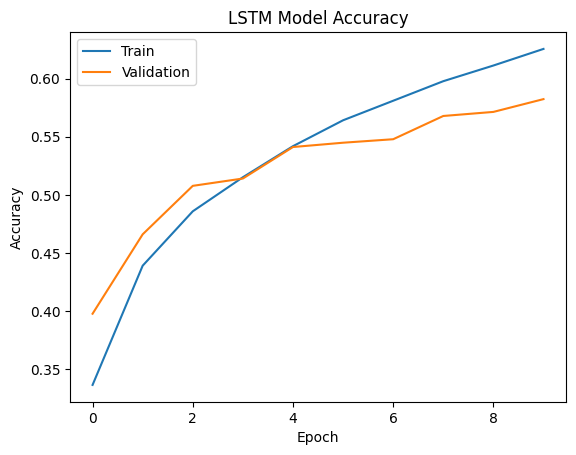

In [43]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

**Evaluate LSTM Model**

In [44]:
lstm_loss, lstm_acc = lstm_model.evaluate(x_test_lstm,y_test)

print("LSTM Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5854 - loss: 1.1709
LSTM Test Accuracy: 0.5823000073432922


**Model Comparison (Bar Chart)**

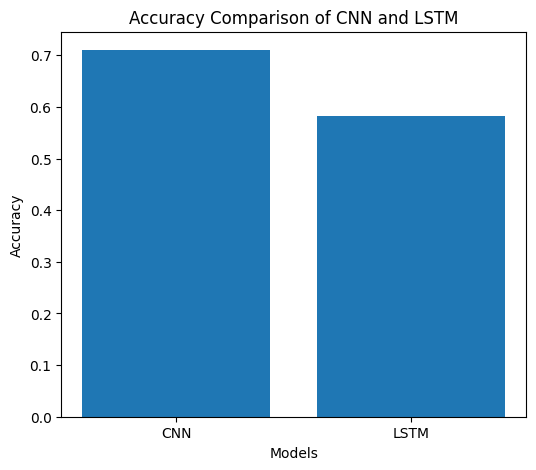

In [45]:
models_names = ['CNN','LSTM']
accuracies = [cnn_acc,lstm_acc]

plt.figure(figsize=(6,5))
plt.bar(models_names,accuracies)

plt.title("Accuracy Comparison of CNN and LSTM")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

**Model Performance Comparison Table**

In [48]:
import pandas as pd

data = {
    "Model": ["CNN", "LSTM"],
    "Accuracy": [cnn_acc, lstm_acc]
}

df = pd.DataFrame(data)

df

,Model,Accuracy
0,CNN,0.7100
1,LSTM,0.5823


**Confusion Matrix (CNN)**

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


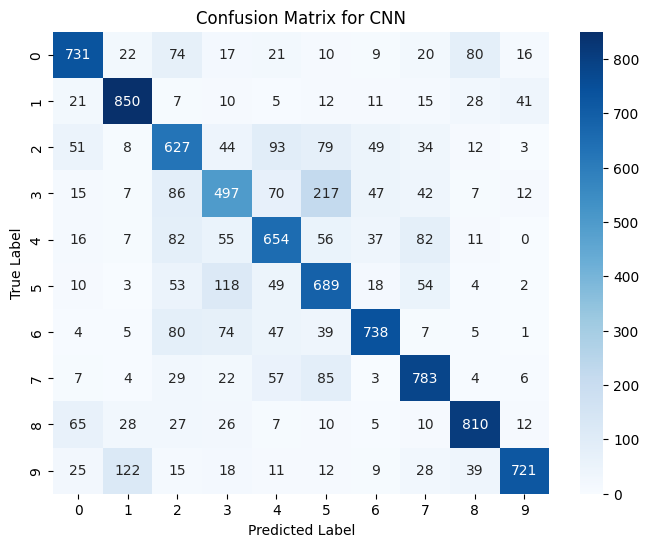

In [46]:
y_pred = cnn_model.predict(x_test)

y_pred_classes = np.argmax(y_pred,axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true,y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix for CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**Sample Predictions Using CNN Model**

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


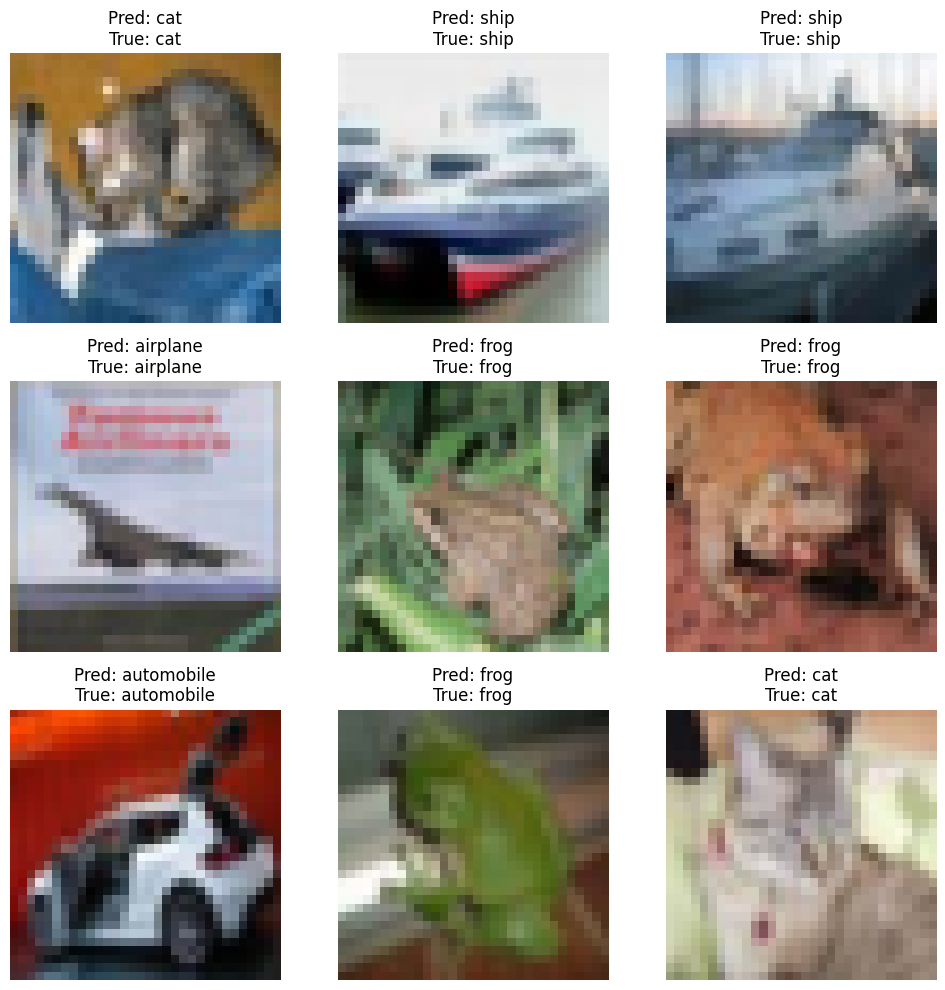

In [47]:
predictions = cnn_model.predict(x_test)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(x_test[i])

    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i][0]]

    plt.title("Pred: "+predicted_label+"\nTrue: "+true_label)

    plt.axis('off')

plt.tight_layout()
plt.show()

**Conclusion**

This project implemented deep learning techniques for image classification using the CIFAR-10 Dataset. The dataset was explored, visualized, and preprocessed before training two models: Convolutional Neural Networks (CNN) and Long Short-Term Memory (LSTM).

The experimental results show that the CNN model achieved higher accuracy than the LSTM model. This outcome highlights the effectiveness of CNN architectures in capturing spatial features from images, making them more suitable for image classification tasks.

Overall, the study demonstrates that CNN-based models provide better performance for image recognition problems and are a reliable approach for datasets like CIFAR-10.